In [ ]:
import pandas as pd
df = pd.read_csv('C:/Users/carlo/Downloads/full_devices.csv', sep=',', encoding='latin-1')

In [2]:
# Análisis de variabilidad temporal de atributos por device
import numpy as np

print("=== ANÁLISIS DE VARIABILIDAD TEMPORAL POR DEVICE ===")

# Convertir date a datetime
df['date'] = pd.to_datetime(df['date'])

# Obtener atributos numéricos excluyendo failure
numeric_cols = df.select_dtypes(include=[np.number]).columns
attribute_cols = [col for col in numeric_cols if col not in ['failure']]

print(f"Atributos a analizar: {attribute_cols}")
print(f"Total de devices: {df['device'].nunique()}")
print(f"Rango de fechas: {df['date'].min()} a {df['date'].max()}")
print(f"Días únicos: {df['date'].nunique()}")


=== ANÁLISIS DE VARIABILIDAD TEMPORAL POR DEVICE ===
Atributos a analizar: ['attribute1', 'attribute2', 'attribute3', 'attribute4', 'attribute5', 'attribute6', 'attribute7', 'attribute8', 'attribute9']
Total de devices: 1169
Rango de fechas: 2015-01-01 00:00:00 a 2015-11-02 00:00:00
Días únicos: 304


In [3]:
# Calcular métricas de variabilidad por device
device_stats = []

for device in df['device'].unique():
    device_data = df[df['device'] == device].sort_values('date')
    
    if len(device_data) < 2:
        continue
    
    # Estadísticas básicas del device
    stats = {
        'device': device,
        'records': len(device_data),
        'days_active': device_data['date'].nunique(),
        'date_span': (device_data['date'].max() - device_data['date'].min()).days,
        'first_date': device_data['date'].min(),
        'last_date': device_data['date'].max()
    }
    
    # Variabilidad por atributo
    for attr in attribute_cols:
        values = device_data[attr].values
        
        if len(values) > 1:
            # Métricas de variabilidad
            cv = values.std() / abs(values.mean()) if values.mean() != 0 else float('inf')
            relative_range = (values.max() - values.min()) / abs(values.mean()) if values.mean() != 0 else float('inf')
            unique_ratio = len(np.unique(values)) / len(values)
            
            stats[f'{attr}_cv'] = cv
            stats[f'{attr}_range'] = relative_range
            stats[f'{attr}_unique_ratio'] = unique_ratio
            stats[f'{attr}_is_constant'] = len(np.unique(values)) == 1
    
    device_stats.append(stats)

device_df = pd.DataFrame(device_stats)
print(f"Dispositivos analizados: {len(device_df)}")
print(f"Dispositivos con múltiples registros: {len(device_df[device_df['records'] > 1])}")


Dispositivos analizados: 1168
Dispositivos con múltiples registros: 1168


In [ ]:
# Función optimizada para calcular rezagos (evita problemas de memoria)
def calculate_lag_features_optimized(df, device_col, date_col, value_col, windows=[7, 15, 30, 60, 90, 120]):
    """
    Calcula rezagos de min, max, mean, std para ventanas específicas por dispositivo
    Optimizada para evitar problemas de memoria
    """
    features = df.copy()
    features = features.sort_values([device_col, date_col])
    
    # Calcular features por dispositivo para evitar problemas de memoria
    for window in windows:
        print(f"  Calculando ventana de {window} días...")
        
        # Inicializar nuevas columnas
        features[f'{value_col}_lag_{window}_min'] = np.nan
        features[f'{value_col}_lag_{window}_max'] = np.nan
        features[f'{value_col}_lag_{window}_mean'] = np.nan
        features[f'{value_col}_lag_{window}_std'] = np.nan
        
        # Procesar cada dispositivo por separado
        for device in features[device_col].unique():
            device_mask = features[device_col] == device
            device_data = features[device_mask].copy()
            
            if len(device_data) == 0:
                continue
                
            # Calcular ventanas deslizantes para este dispositivo
            for i in range(len(device_data)):
                # Ventana hacia atrás desde la fecha actual
                end_idx = i + 1
                start_idx = max(0, end_idx - window)
                
                # Obtener valores en la ventana
                window_values = device_data[value_col].iloc[start_idx:end_idx]
                
                # Calcular estadísticas
                if len(window_values) > 0:
                    features.loc[device_mask, f'{value_col}_lag_{window}_min'].iloc[i] = window_values.min()
                    features.loc[device_mask, f'{value_col}_lag_{window}_max'].iloc[i] = window_values.max()
                    features.loc[device_mask, f'{value_col}_lag_{window}_mean'].iloc[i] = window_values.mean()
                    features.loc[device_mask, f'{value_col}_lag_{window}_std'].iloc[i] = window_values.std()
    
    return features

print("Función optimizada creada")


In [ ]:
# Aplicar ingeniería de variables optimizada
print("=== PROCESANDO ATRIBUTOS CON FUNCIÓN OPTIMIZADA ===")

# Definir atributos según análisis anterior
high_variability_attrs = ['attribute1', 'attribute5', 'attribute6']  # Variables
low_variability_attrs = ['attribute2', 'attribute3', 'attribute4', 'attribute7', 'attribute8', 'attribute9']  # Invariables

print(f"Atributos de alta variabilidad: {high_variability_attrs}")
print(f"Atributos de baja variabilidad: {low_variability_attrs}")

# Crear features para atributos de alta variabilidad (rezagos)
df_with_features = df.copy()

for attr in high_variability_attrs:
    print(f"\nProcesando {attr}...")
    
    # Calcular rezagos con ventanas deslizantes (optimizado)
    df_with_features = calculate_lag_features_optimized(
        df_with_features, 
        device_col='device', 
        date_col='date', 
        value_col=attr, 
        windows=[7, 15, 30, 60, 90, 120]
    )
    
    print(f"  ✅ Features creados para {attr}: 24 nuevas columnas (4 estadísticas × 6 ventanas)")

print(f"\nDataset después de procesar alta variabilidad:")
print(f"Shape original: {df.shape}")
print(f"Shape actual: {df_with_features.shape}")
print(f"Nuevas columnas agregadas: {df_with_features.shape[1] - df.shape[1]}")


In [ ]:
# Función para calcular tasa de cambio (optimizada)
def calculate_change_rate_features_optimized(df, device_col, date_col, value_col):
    """
    Calcula tasa de cambio y tasa de cambio acumulada por dispositivo
    """
    features = df.copy()
    features = features.sort_values([device_col, date_col])
    
    # Inicializar nuevas columnas
    features[f'{value_col}_change_rate'] = np.nan
    features[f'{value_col}_cumulative_change'] = np.nan
    
    # Procesar cada dispositivo por separado
    for device in features[device_col].unique():
        device_mask = features[device_col] == device
        device_data = features[device_mask].copy()
        
        if len(device_data) < 2:
            continue
            
        values = device_data[value_col].values
        
        # Calcular tasa de cambio (diferencia porcentual)
        change_rates = np.zeros(len(values))
        change_rates[1:] = np.diff(values) / values[:-1]
        change_rates[0] = np.nan  # Primer valor no tiene cambio
        
        # Calcular tasa de cambio acumulada
        cumulative_changes = np.nan_to_num(change_rates).cumsum()
        cumulative_changes[np.isnan(change_rates)] = np.nan
        
        # Asignar valores
        features.loc[device_mask, f'{value_col}_change_rate'] = change_rates
        features.loc[device_mask, f'{value_col}_cumulative_change'] = cumulative_changes
    
    return features

# Aplicar ingeniería para atributos de baja variabilidad
print("=== PROCESANDO ATRIBUTOS DE BAJA VARIABILIDAD ===")

for attr in low_variability_attrs:
    print(f"Procesando {attr}...")
    
    # Calcular tasa de cambio y tasa de cambio acumulada
    df_with_features = calculate_change_rate_features_optimized(
        df_with_features, 
        device_col='device', 
        date_col='date', 
        value_col=attr
    )
    
    print(f"  ✅ Features creados para {attr}: 2 nuevas columnas (change_rate, cumulative_change)")

print(f"\nDataset final después de procesar baja variabilidad:")
print(f"Shape original: {df.shape}")
print(f"Shape final: {df_with_features.shape}")
print(f"Total nuevas columnas: {df_with_features.shape[1] - df.shape[1]}")


In [ ]:
# Verificar features creadas
print("=== VERIFICACIÓN DE FEATURES CREADAS ===")

# Mostrar nuevas columnas
new_columns = [col for col in df_with_features.columns if col not in df.columns]
print(f"Total nuevas columnas: {len(new_columns)}")
print(f"Columnas originales: {len(df.columns)}")
print(f"Columnas finales: {len(df_with_features.columns)}")

# Mostrar ejemplo de features
sample_device = df_with_features['device'].iloc[0]
device_sample = df_with_features[df_with_features['device'] == sample_device].head(3)

print(f"\nEjemplo para dispositivo: {sample_device}")
print("Primeras 3 filas con algunas features:")

# Seleccionar columnas para mostrar
cols_to_show = ['device', 'date', 'attribute1'] + [col for col in df_with_features.columns if 'attribute1_lag_7' in col]
print(device_sample[cols_to_show].to_string(index=False))

print(f"\n=== RESUMEN FINAL ===")
print(f"Features de alta variabilidad: {len(high_variability_attrs) * 24} (3 atributos × 24 features)")
print(f"Features de baja variabilidad: {len(low_variability_attrs) * 2} (6 atributos × 2 features)")
print(f"Total features creadas: {len(new_columns)}")
print(f"✅ Ingeniería de variables completada exitosamente")


In [ ]:
# Guardar dataset con features de ingeniería en formato Parquet
print("=== GUARDANDO DATASET CON FEATURES ===")

# Crear nombre del archivo con timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f'full_devices_with_features_{timestamp}.parquet'

# Guardar el dataset en formato Parquet
df_with_features.to_parquet(output_filename, index=False)

print(f"✅ Dataset guardado exitosamente:")
print(f"Archivo: {output_filename}")
print(f"Formato: Parquet")
print(f"Shape: {df_with_features.shape}")
print(f"Columnas originales: {len(df.columns)}")
print(f"Columnas con features: {len(df_with_features.columns)}")
print(f"Nuevas features creadas: {len(df_with_features.columns) - len(df.columns)}")

# Mostrar resumen de features por tipo
print(f"\n=== RESUMEN DE FEATURES GUARDADAS ===")
high_var_features = [col for col in df_with_features.columns if any(attr in col for attr in high_variability_attrs) and col not in df.columns]
low_var_features = [col for col in df_with_features.columns if any(attr in col for attr in low_variability_attrs) and col not in df.columns]

print(f"Features de alta variabilidad: {len(high_var_features)}")
print(f"Features de baja variabilidad: {len(low_var_features)}")
print(f"Total features nuevas: {len(high_var_features) + len(low_var_features)}")

print(f"\nVentajas del formato Parquet:")
print(f"- Compresión eficiente")
print(f"- Preserva tipos de datos")
print(f"- Lectura rápida")
print(f"- Compatible con pandas, spark, etc.")

print(f"\nDataset listo para modelado con {len(df_with_features.columns)} columnas")


In [ ]:
# Probar ingeniería de variables con un solo dispositivo
print("=== PRUEBA CON UN SOLO DISPOSITIVO ===")

# Filtrar solo un dispositivo para probar
test_device = 'S1F01R2B'
df_test = df[df['device'] == test_device].copy()
df_test = df_test.sort_values('date')

print(f"Dispositivo de prueba: {test_device}")
print(f"Registros del dispositivo: {len(df_test)}")
print(f"Rango de fechas: {df_test['date'].min()} a {df_test['date'].max()}")

# Mostrar datos originales
print(f"\nDatos originales del dispositivo:")
print(df_test[['device', 'date', 'attribute1', 'attribute5', 'attribute6']].head(10))


In [ ]:
# Función simple para calcular rezagos de un solo dispositivo
def calculate_lag_features_simple(df_single_device, value_col, windows=[7, 15, 30]):
    """
    Calcula rezagos para un solo dispositivo
    """
    result = df_single_device.copy()
    result = result.sort_values('date')
    
    for window in windows:
        print(f"Calculando ventana de {window} días para {value_col}...")
        
        # Inicializar columnas
        result[f'{value_col}_lag_{window}_min'] = np.nan
        result[f'{value_col}_lag_{window}_max'] = np.nan
        result[f'{value_col}_lag_{window}_mean'] = np.nan
        result[f'{value_col}_lag_{window}_std'] = np.nan
        
        values = result[value_col].values
        
        # Calcular ventana deslizante
        for i in range(len(values)):
            # Ventana hacia atrás
            start_idx = max(0, i - window + 1)
            end_idx = i + 1
            
            window_values = values[start_idx:end_idx]
            
            if len(window_values) > 0:
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_min')] = window_values.min()
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_max')] = window_values.max()
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_mean')] = window_values.mean()
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_std')] = window_values.std()
    
    return result

# Probar con attribute1
print("=== PROBANDO CON ATTRIBUTE1 ===")
df_test_with_lags = calculate_lag_features_simple(df_test, 'attribute1', windows=[7, 15, 30])

print(f"\nResultado con rezagos:")
cols_to_show = ['device', 'date', 'attribute1'] + [col for col in df_test_with_lags.columns if 'attribute1_lag' in col]
print(df_test_with_lags[cols_to_show].head(10))


In [ ]:
# Verificar manualmente algunos cálculos
print("=== VERIFICACIÓN MANUAL DE CÁLCULOS ===")

# Tomar las primeras 10 filas para verificar
sample = df_test_with_lags.head(10)

print("Verificación de attribute1_lag_7_mean:")
for i in range(min(7, len(sample))):
    row = sample.iloc[i]
    original_value = row['attribute1']
    lag_mean = row['attribute1_lag_7_mean']
    
    # Calcular manualmente el promedio de los últimos 7 días
    if i >= 6:  # Si tenemos al menos 7 registros
        manual_mean = sample['attribute1'].iloc[max(0, i-6):i+1].mean()
        print(f"Fila {i}: Original={original_value}, Lag_Mean={lag_mean:.2f}, Manual={manual_mean:.2f}")
    else:
        print(f"Fila {i}: Original={original_value}, Lag_Mean={lag_mean:.2f} (menos de 7 registros)")

print(f"\nVerificación de attribute1_lag_15_max:")
for i in range(min(15, len(sample))):
    row = sample.iloc[i]
    original_value = row['attribute1']
    lag_max = row['attribute1_lag_15_max']
    
    if i >= 14:  # Si tenemos al menos 15 registros
        manual_max = sample['attribute1'].iloc[max(0, i-14):i+1].max()
        print(f"Fila {i}: Original={original_value}, Lag_Max={lag_max:.2f}, Manual={manual_max:.2f}")
    else:
        print(f"Fila {i}: Original={original_value}, Lag_Max={lag_max:.2f} (menos de 15 registros)")
        break


In [ ]:
# Probar función para tasa de cambio
def calculate_change_rate_simple(df_single_device, value_col):
    """
    Calcula tasa de cambio para un solo dispositivo
    """
    result = df_single_device.copy()
    result = result.sort_values('date')
    
    values = result[value_col].values
    
    # Calcular tasa de cambio
    change_rates = np.zeros(len(values))
    change_rates[1:] = np.diff(values) / values[:-1]
    change_rates[0] = np.nan  # Primer valor no tiene cambio
    
    # Calcular tasa de cambio acumulada
    cumulative_changes = np.nan_to_num(change_rates).cumsum()
    cumulative_changes[np.isnan(change_rates)] = np.nan
    
    result[f'{value_col}_change_rate'] = change_rates
    result[f'{value_col}_cumulative_change'] = cumulative_changes
    
    return result

# Probar con attribute2 (baja variabilidad)
print("=== PROBANDO TASA DE CAMBIO CON ATTRIBUTE2 ===")
df_test_with_change = calculate_change_rate_simple(df_test, 'attribute2')

print(f"\nResultado con tasa de cambio:")
cols_to_show = ['device', 'date', 'attribute2', 'attribute2_change_rate', 'attribute2_cumulative_change']
print(df_test_with_change[cols_to_show].head(10))

# Verificar manualmente
print(f"\n=== VERIFICACIÓN MANUAL DE TASA DE CAMBIO ===")
sample_change = df_test_with_change.head(5)
for i in range(1, len(sample_change)):
    prev_val = sample_change.iloc[i-1]['attribute2']
    curr_val = sample_change.iloc[i]['attribute2']
    calc_change = sample_change.iloc[i]['attribute2_change_rate']
    
    if prev_val != 0:
        manual_change = (curr_val - prev_val) / prev_val
        print(f"Fila {i}: {prev_val} → {curr_val}, Calculado={calc_change:.4f}, Manual={manual_change:.4f}")
    else:
        print(f"Fila {i}: {prev_val} → {curr_val}, Calculado={calc_change:.4f} (división por cero)")


In [ ]:
# Aplicar ingeniería de variables a todo el dataset
print("=== APLICANDO INGENIERÍA A TODO EL DATASET ===")

# Crear copia del dataset ordenado
df_final = df.copy()
df_final = df_final.sort_values(['device', 'date'])

print(f"Dataset original: {df_final.shape}")
print(f"Dispositivos únicos: {df_final['device'].nunique()}")

# Definir atributos
high_variability_attrs = ['attribute1', 'attribute5', 'attribute6']  # Variables
low_variability_attrs = ['attribute2', 'attribute3', 'attribute4', 'attribute7', 'attribute8', 'attribute9']  # Invariables

print(f"Atributos de alta variabilidad: {high_variability_attrs}")
print(f"Atributos de baja variabilidad: {low_variability_attrs}")


In [ ]:
# Función escalable para calcular rezagos en todo el dataset
def calculate_lag_features_dataset(df, value_col, windows=[7, 15, 30, 60, 90, 120]):
    """
    Calcula rezagos para todo el dataset procesando por dispositivo
    """
    result = df.copy()
    
    # Inicializar columnas
    for window in windows:
        result[f'{value_col}_lag_{window}_min'] = np.nan
        result[f'{value_col}_lag_{window}_max'] = np.nan
        result[f'{value_col}_lag_{window}_mean'] = np.nan
        result[f'{value_col}_lag_{window}_std'] = np.nan
    
    # Procesar cada dispositivo
    devices = df['device'].unique()
    total_devices = len(devices)
    
    for idx, device in enumerate(devices):
        if idx % 100 == 0:
            print(f"  Procesando dispositivo {idx+1}/{total_devices}: {device}")
        
        device_mask = df['device'] == device
        device_data = df[device_mask].sort_values('date')
        
        if len(device_data) == 0:
            continue
        
        values = device_data[value_col].values
        
        # Calcular para cada ventana
        for window in windows:
            for i in range(len(values)):
                # Ventana hacia atrás
                start_idx = max(0, i - window + 1)
                end_idx = i + 1
                
                window_values = values[start_idx:end_idx]
                
                if len(window_values) > 0:
                    # Obtener índices en el dataframe original
                    device_indices = device_data.index[start_idx:end_idx]
                    
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_min'] = window_values.min()
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_max'] = window_values.max()
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_mean'] = window_values.mean()
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_std'] = window_values.std()
    
    return result

# Aplicar rezagos para atributos de alta variabilidad
print("=== PROCESANDO ATRIBUTOS DE ALTA VARIABILIDAD ===")

for attr in high_variability_attrs:
    print(f"\nProcesando {attr}...")
    df_final = calculate_lag_features_dataset(
        df_final, 
        attr, 
        windows=[7, 15, 30, 60, 90, 120]
    )
    print(f"  ✅ Completado {attr}")

print(f"\nDataset después de alta variabilidad: {df_final.shape}")


In [ ]:
# Función escalable para calcular tasas de cambio en todo el dataset
def calculate_change_rate_dataset(df, value_col):
    """
    Calcula tasa de cambio y acumulada para todo el dataset procesando por dispositivo
    """
    result = df.copy()
    
    # Inicializar columnas
    result[f'{value_col}_change_rate'] = np.nan
    result[f'{value_col}_cumulative_change'] = np.nan
    
    # Procesar cada dispositivo
    devices = df['device'].unique()
    total_devices = len(devices)
    
    for idx, device in enumerate(devices):
        if idx % 100 == 0:
            print(f"  Procesando dispositivo {idx+1}/{total_devices}: {device}")
        
        device_mask = df['device'] == device
        device_data = df[device_mask].sort_values('date')
        
        if len(device_data) < 2:
            continue
        
        values = device_data[value_col].values
        
        # Calcular tasa de cambio
        change_rates = np.zeros(len(values))
        change_rates[1:] = np.diff(values) / values[:-1]
        change_rates[0] = np.nan  # Primer valor no tiene cambio
        
        # Calcular tasa de cambio acumulada
        cumulative_changes = np.nan_to_num(change_rates).cumsum()
        cumulative_changes[np.isnan(change_rates)] = np.nan
        
        # Asignar valores
        result.loc[device_data.index, f'{value_col}_change_rate'] = change_rates
        result.loc[device_data.index, f'{value_col}_cumulative_change'] = cumulative_changes
    
    return result

# Aplicar tasas de cambio para atributos de baja variabilidad
print("=== PROCESANDO ATRIBUTOS DE BAJA VARIABILIDAD ===")

for attr in low_variability_attrs:
    print(f"\nProcesando {attr}...")
    df_final = calculate_change_rate_dataset(df_final, attr)
    print(f"  ✅ Completado {attr}")

print(f"\nDataset final: {df_final.shape}")


In [ ]:
# Verificar y mostrar resumen de features creadas
print("=== VERIFICACIÓN Y RESUMEN DE FEATURES ===")

# Mostrar nuevas columnas
original_cols = df.columns.tolist()
new_cols = [col for col in df_final.columns if col not in original_cols]

print(f"Columnas originales: {len(original_cols)}")
print(f"Columnas finales: {len(df_final.columns)}")
print(f"Nuevas features creadas: {len(new_cols)}")

# Contar features por tipo
lag_features = [col for col in new_cols if '_lag_' in col]
change_features = [col for col in new_cols if '_change_' in col]

print(f"\nFeatures de rezagos (alta variabilidad): {len(lag_features)}")
print(f"Features de tasa de cambio (baja variabilidad): {len(change_features)}")

# Mostrar ejemplo de features para un dispositivo
test_device = 'S1F01R2B'
device_sample = df_final[df_final['device'] == test_device].head(3)

print(f"\nEjemplo para dispositivo {test_device}:")
print("Primeras 3 filas con algunas features:")

# Mostrar columnas originales + algunas nuevas
cols_to_show = ['device', 'date', 'attribute1', 'attribute2'] + [col for col in new_cols if 'attribute1_lag_7' in col or 'attribute2_change' in col]
print(device_sample[cols_to_show].to_string(index=False))

print(f"\n✅ Ingeniería de variables completada exitosamente")
print(f"Dataset listo para modelado con {len(df_final.columns)} columnas")


In [ ]:
# Guardar dataset final en formato Parquet
print("=== GUARDANDO DATASET FINAL ===")

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f'full_devices_with_features_{timestamp}.parquet'

# Guardar el dataset
df_final.to_parquet(output_filename, index=False)

print(f"✅ Dataset guardado exitosamente:")
print(f"Archivo: {output_filename}")
print(f"Formato: Parquet")
print(f"Shape: {df_final.shape}")
print(f"Columnas originales: {len(original_cols)}")
print(f"Columnas con features: {len(df_final.columns)}")
print(f"Nuevas features: {len(new_cols)}")

print(f"\n=== RESUMEN FINAL ===")
print(f"Features de alta variabilidad: {len(lag_features)} (3 atributos × 24 features)")
print(f"Features de baja variabilidad: {len(change_features)} (6 atributos × 2 features)")
print(f"Total features creadas: {len(new_cols)}")

print(f"\nVentajas del formato Parquet:")
print(f"- Compresión eficiente")
print(f"- Preserva tipos de datos")
print(f"- Lectura rápida")
print(f"- Compatible con pandas, spark, etc.")

print(f"\nDataset listo para modelado con {len(df_final.columns)} columnas")


In [4]:
# Análisis de variabilidad por atributo
print("=== RESUMEN DE VARIABILIDAD POR ATRIBUTO ===")

for attr in attribute_cols:
    print(f"\n{attr}:")
    
    # Dispositivos con múltiples registros
    multi_record_devices = device_df[device_df['records'] > 1]
    
    if len(multi_record_devices) > 0:
        # Métricas de variabilidad
        cv_values = multi_record_devices[f'{attr}_cv'].replace([np.inf, -np.inf], np.nan)
        range_values = multi_record_devices[f'{attr}_range'].replace([np.inf, -np.inf], np.nan)
        unique_ratios = multi_record_devices[f'{attr}_unique_ratio']
        
        # Dispositivos constantes
        constant_devices = multi_record_devices[f'{attr}_is_constant'].sum()
        variable_devices = len(multi_record_devices) - constant_devices
        
        print(f"  Dispositivos con múltiples registros: {len(multi_record_devices)}")
        print(f"  Dispositivos con valores constantes: {constant_devices} ({constant_devices/len(multi_record_devices)*100:.1f}%)")
        print(f"  Dispositivos con valores variables: {variable_devices} ({variable_devices/len(multi_record_devices)*100:.1f}%)")
        
        if variable_devices > 0:
            print(f"  Coeficiente de variación promedio: {cv_values.mean():.4f}")
            print(f"  Rango relativo promedio: {range_values.mean():.4f}")
            print(f"  Ratio único promedio: {unique_ratios.mean():.4f}")
        
        # Clasificar atributo
        if constant_devices / len(multi_record_devices) > 0.8:
            print(f"  🟢 ATRIBUTO INVARIABLE - {constant_devices/len(multi_record_devices)*100:.1f}% de devices constantes")
        else:
            print(f"  🔴 ATRIBUTO VARIABLE - {variable_devices/len(multi_record_devices)*100:.1f}% de devices variables")
    else:
        print(f"  No hay dispositivos con múltiples registros para analizar")


=== RESUMEN DE VARIABILIDAD POR ATRIBUTO ===

attribute1:
  Dispositivos con múltiples registros: 1168
  Dispositivos con valores constantes: 0 (0.0%)
  Dispositivos con valores variables: 1168 (100.0%)
  Coeficiente de variación promedio: 0.5473
  Rango relativo promedio: 1.7663
  Ratio único promedio: 0.9840
  🔴 ATRIBUTO VARIABLE - 100.0% de devices variables

attribute2:
  Dispositivos con múltiples registros: 1168
  Dispositivos con valores constantes: 1065 (91.2%)
  Dispositivos con valores variables: 103 (8.8%)
  Coeficiente de variación promedio: 1.2206
  Rango relativo promedio: 8.4863
  Ratio único promedio: 0.0774
  🟢 ATRIBUTO INVARIABLE - 91.2% de devices constantes

attribute3:
  Dispositivos con múltiples registros: 1168
  Dispositivos con valores constantes: 1158 (99.1%)
  Dispositivos con valores variables: 10 (0.9%)
  Coeficiente de variación promedio: 0.2185
  Rango relativo promedio: 1.5845
  Ratio único promedio: 0.0640
  🟢 ATRIBUTO INVARIABLE - 99.1% de devices cons

In [5]:
# Análisis de presencia temporal de devices
print("=== ANÁLISIS DE PRESENCIA TEMPORAL ===")

# Calcular días únicos totales
total_days = df['date'].nunique()
print(f"Días únicos en el dataset: {total_days}")

# Para cada device, calcular presencia temporal
presence_stats = []

for device in df['device'].unique():
    device_data = df[df['device'] == device]
    
    days_active = device_data['date'].nunique()
    total_records = len(device_data)
    
    # Calcular presencia porcentual
    presence_pct = (days_active / total_days) * 100
    
    # Calcular frecuencia de registros por día
    avg_records_per_day = total_records / days_active if days_active > 0 else 0
    
    presence_stats.append({
        'device': device,
        'days_active': days_active,
        'total_records': total_records,
        'presence_pct': presence_pct,
        'avg_records_per_day': avg_records_per_day,
        'first_date': device_data['date'].min(),
        'last_date': device_data['date'].max()
    })

presence_df = pd.DataFrame(presence_stats)

print(f"Dispositivos presentes en >90% de días: {(presence_df['presence_pct'] >= 90).sum()}")
print(f"Dispositivos presentes en >50% de días: {(presence_df['presence_pct'] >= 50).sum()}")
print(f"Dispositivos presentes en <10% de días: {(presence_df['presence_pct'] < 10).sum()}")

print(f"\nPresencia promedio: {presence_df['presence_pct'].mean():.1f}%")
print(f"Presencia mediana: {presence_df['presence_pct'].median():.1f}%")


=== ANÁLISIS DE PRESENCIA TEMPORAL ===
Días únicos en el dataset: 304
Dispositivos presentes en >90% de días: 131
Dispositivos presentes en >50% de días: 345
Dispositivos presentes en <10% de días: 432

Presencia promedio: 35.0%
Presencia mediana: 27.6%


In [6]:
# CONCLUSIÓN: Estrategia de ingeniería de variables
print("=== RECOMENDACIÓN DE INGENIERÍA DE VARIABLES ===")

# Contar atributos variables vs invariables
variable_attrs = []
invariable_attrs = []

for attr in attribute_cols:
    multi_record_devices = device_df[device_df['records'] > 1]
    if len(multi_record_devices) > 0:
        constant_devices = multi_record_devices[f'{attr}_is_constant'].sum()
        if constant_devices / len(multi_record_devices) > 0.8:
            invariable_attrs.append(attr)
        else:
            variable_attrs.append(attr)

print(f"Atributos INVARIABLES ({len(invariable_attrs)}): {invariable_attrs}")
print(f"Atributos VARIABLES ({len(variable_attrs)}): {variable_attrs}")

# Análisis de presencia
high_presence_devices = (presence_df['presence_pct'] >= 90).sum()
total_devices = len(presence_df)

print(f"\nDispositivos con alta presencia (≥90% días): {high_presence_devices} de {total_devices} ({high_presence_devices/total_devices*100:.1f}%)")

# Recomendación final
print("\n=== ESTRATEGIA RECOMENDADA ===")

if high_presence_devices / total_devices > 0.5:
    print("🟢 GRANULARIDAD DIARIA RECOMENDADA")
    print("   - La mayoría de devices están presentes la mayoría de días")
    print("   - Construir features diarios usando date")
    print("   - Atributos invariables: usar valores únicos por device")
    print("   - Atributos variables: usar agregaciones temporales (promedio, std, etc.)")
else:
    print("🟡 GRANULARIDAD MENSUAL RECOMENDADA")
    print("   - Muchos devices tienen presencia intermitente")
    print("   - Construir features mensuales usando date_trunc")
    print("   - Atributos invariables: usar valores únicos por device")
    print("   - Atributos variables: usar agregaciones mensuales")

print(f"\nFeatures a construir:")
print(f"- Atributos invariables ({len(invariable_attrs)}): valores únicos por device")
print(f"- Atributos variables ({len(variable_attrs)}): agregaciones temporales")
print(f"- Features de presencia: días activos, frecuencia de registros")
print(f"- Features de failure: tasa de failure por device")


=== RECOMENDACIÓN DE INGENIERÍA DE VARIABLES ===
Atributos INVARIABLES (6): ['attribute2', 'attribute3', 'attribute4', 'attribute7', 'attribute8', 'attribute9']
Atributos VARIABLES (3): ['attribute1', 'attribute5', 'attribute6']

Dispositivos con alta presencia (≥90% días): 131 de 1169 (11.2%)

=== ESTRATEGIA RECOMENDADA ===
🟡 GRANULARIDAD MENSUAL RECOMENDADA
   - Muchos devices tienen presencia intermitente
   - Construir features mensuales usando date_trunc
   - Atributos invariables: usar valores únicos por device
   - Atributos variables: usar agregaciones mensuales

Features a construir:
- Atributos invariables (6): valores únicos por device
- Atributos variables (3): agregaciones temporales
- Features de presencia: días activos, frecuencia de registros
- Features de failure: tasa de failure por device


In [7]:
# Describe de cada atributo
print("=== DESCRIPCIÓN ESTADÍSTICA POR ATRIBUTO ===")

for attr in attribute_cols:
    print(f"\n{attr.upper()}:")
    print("-" * 50)
    print(df[attr].describe().round(4))
    
    # Estadísticas adicionales
    print(f"Valores únicos: {df[attr].nunique()}")
    print(f"Valores nulos: {df[attr].isnull().sum()}")
    print(f"Valores cero: {(df[attr] == 0).sum()}")
    print(f"Porcentaje de ceros: {(df[attr] == 0).sum() / len(df) * 100:.2f}%")
    
    # Percentiles adicionales
    print(f"Percentil 95: {df[attr].quantile(0.95):.4f}")
    print(f"Percentil 99: {df[attr].quantile(0.99):.4f}")
    print(f"Valor máximo: {df[attr].max():.4f}")


=== DESCRIPCIÓN ESTADÍSTICA POR ATRIBUTO ===

ATTRIBUTE1:
--------------------------------------------------
count    1.244940e+05
mean     1.223881e+08
std      7.045933e+07
min      0.000000e+00
25%      6.128476e+07
50%      1.227974e+08
75%      1.833096e+08
max      2.441405e+08
Name: attribute1, dtype: float64
Valores únicos: 123877
Valores nulos: 0
Valores cero: 11
Porcentaje de ceros: 0.01%
Percentil 95: 231873846.4000
Percentil 99: 241791145.3600
Valor máximo: 244140480.0000

ATTRIBUTE2:
--------------------------------------------------
count    124494.0000
mean        159.4848
std        2179.6577
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max       64968.0000
Name: attribute2, dtype: float64
Valores únicos: 558
Valores nulos: 0
Valores cero: 118110
Porcentaje de ceros: 94.87%
Percentil 95: 8.0000
Percentil 99: 2664.0000
Valor máximo: 64968.0000

ATTRIBUTE3:
--------------------------------------------------
count    124494.0000
mean 

=== GRÁFICOS TEMPORALES POR ATRIBUTO ===


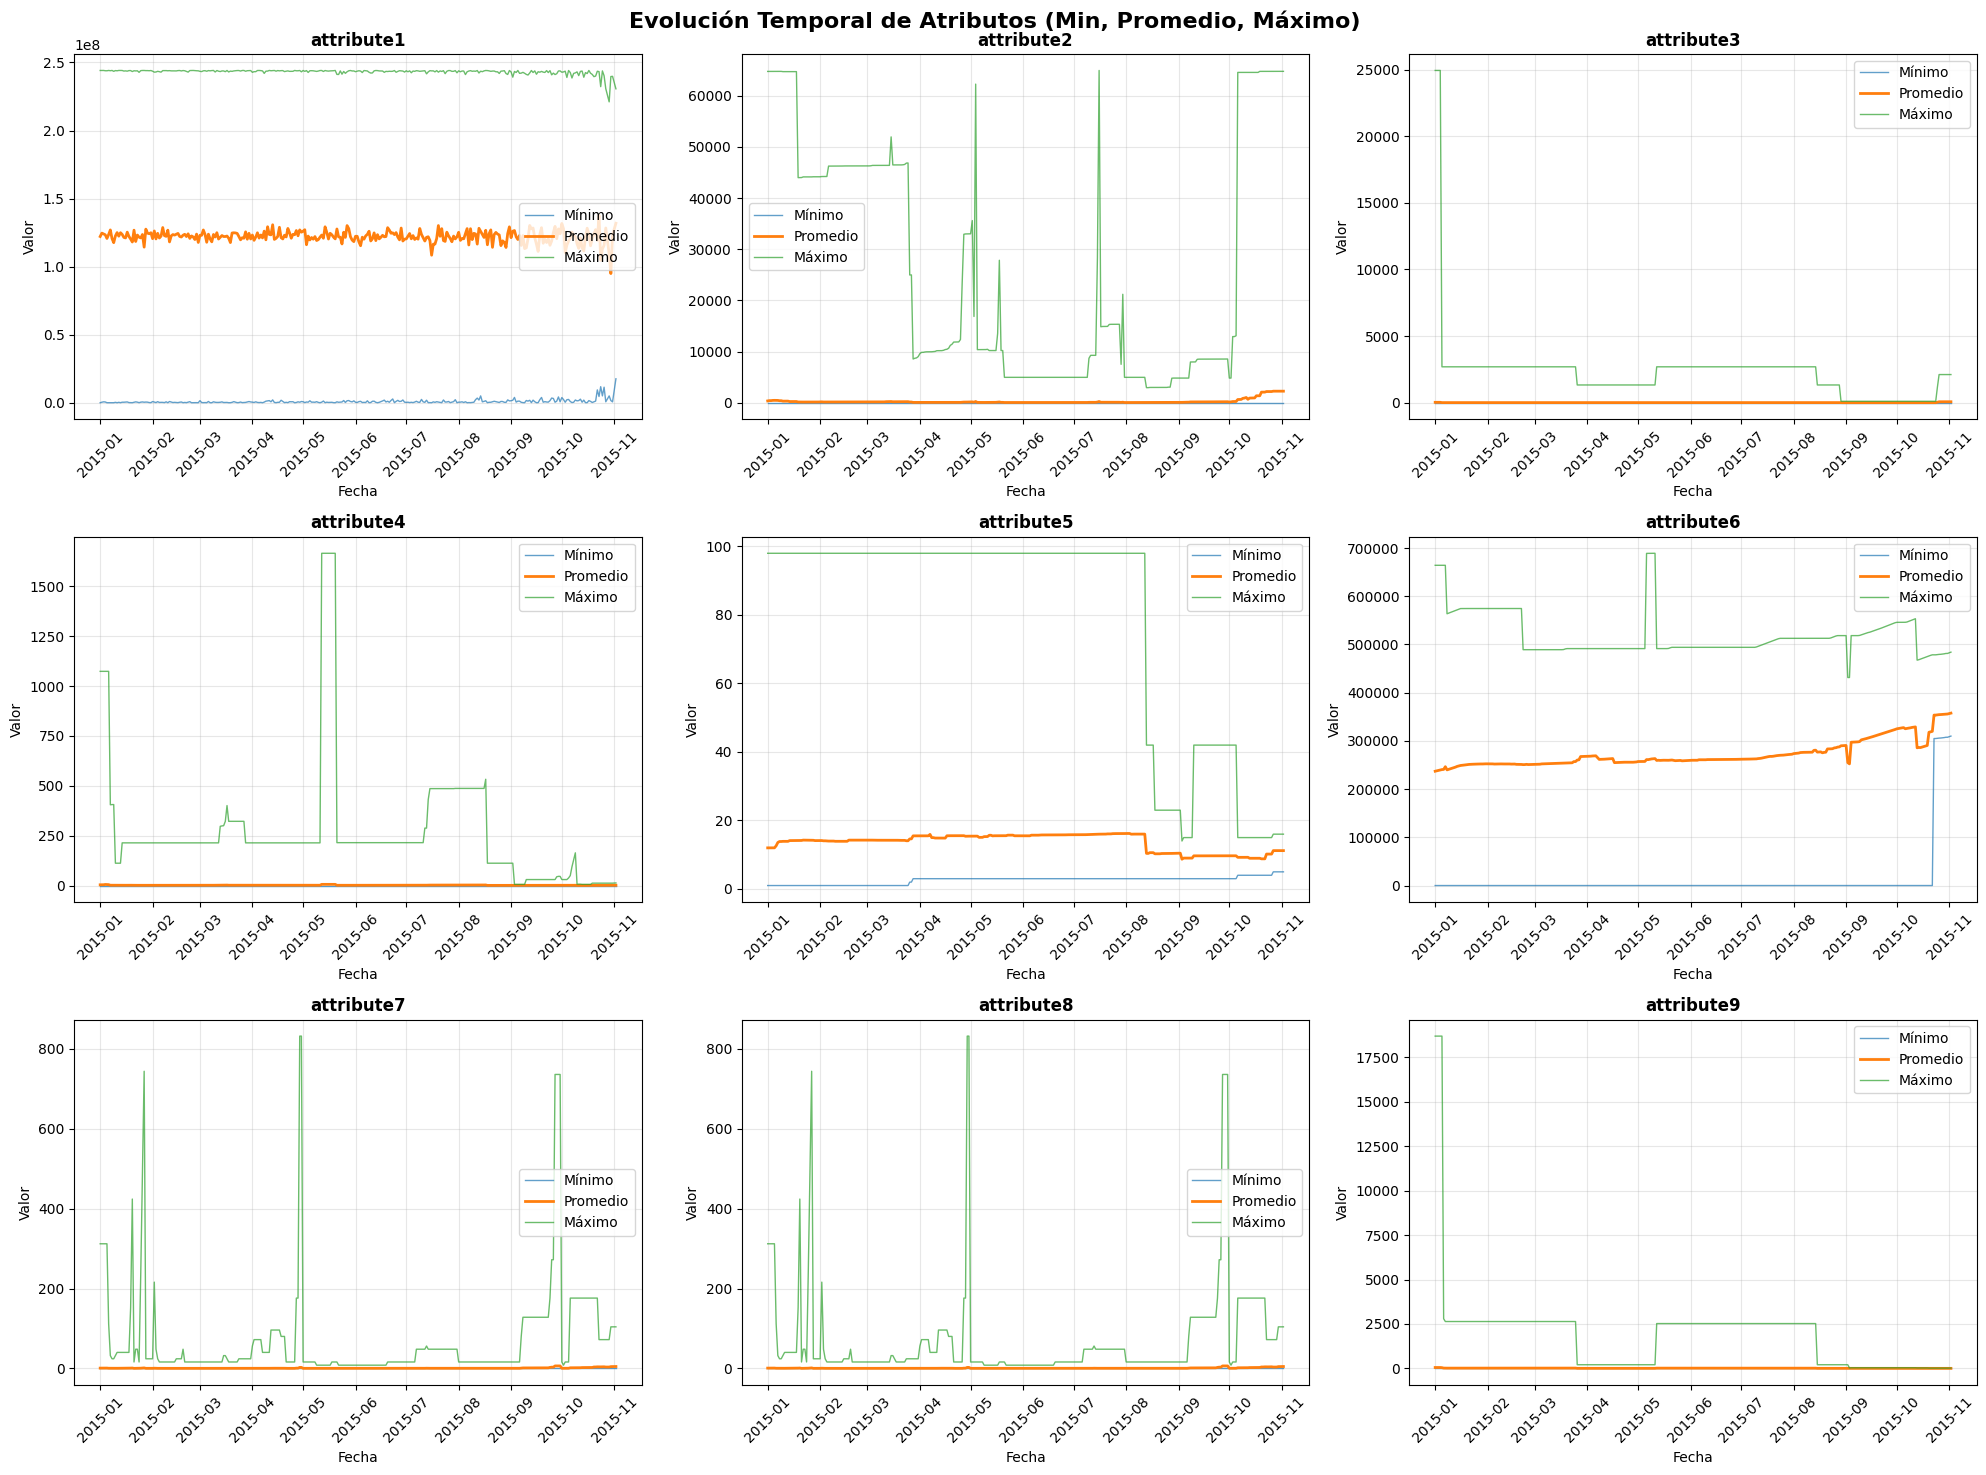

Gráficos temporales generados


In [8]:
# Gráficos temporales de min, promedio y máximo por atributo
import matplotlib.pyplot as plt

print("=== GRÁFICOS TEMPORALES POR ATRIBUTO ===")

# Crear gráficos para cada atributo
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Evolución Temporal de Atributos (Min, Promedio, Máximo)', fontsize=16, fontweight='bold')

# Aplanar axes para iterar fácilmente
axes_flat = axes.flatten()

for i, attr in enumerate(attribute_cols):
    if i >= len(axes_flat):
        break
    
    # Calcular estadísticas por fecha
    daily_stats = df.groupby('date')[attr].agg(['min', 'mean', 'max']).reset_index()
    
    # Graficar
    axes_flat[i].plot(daily_stats['date'], daily_stats['min'], label='Mínimo', alpha=0.7, linewidth=1)
    axes_flat[i].plot(daily_stats['date'], daily_stats['mean'], label='Promedio', linewidth=2)
    axes_flat[i].plot(daily_stats['date'], daily_stats['max'], label='Máximo', alpha=0.7, linewidth=1)
    
    # Configurar gráfico
    axes_flat[i].set_title(f'{attr}', fontweight='bold')
    axes_flat[i].set_xlabel('Fecha')
    axes_flat[i].set_ylabel('Valor')
    axes_flat[i].legend()
    axes_flat[i].grid(True, alpha=0.3)
    
    # Rotar etiquetas de fecha
    axes_flat[i].tick_params(axis='x', rotation=45)

# Ocultar subplots vacíos
for i in range(len(attribute_cols), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

print("Gráficos temporales generados")


=== GRÁFICOS DETALLADOS DE ATRIBUTOS VARIABLES ===


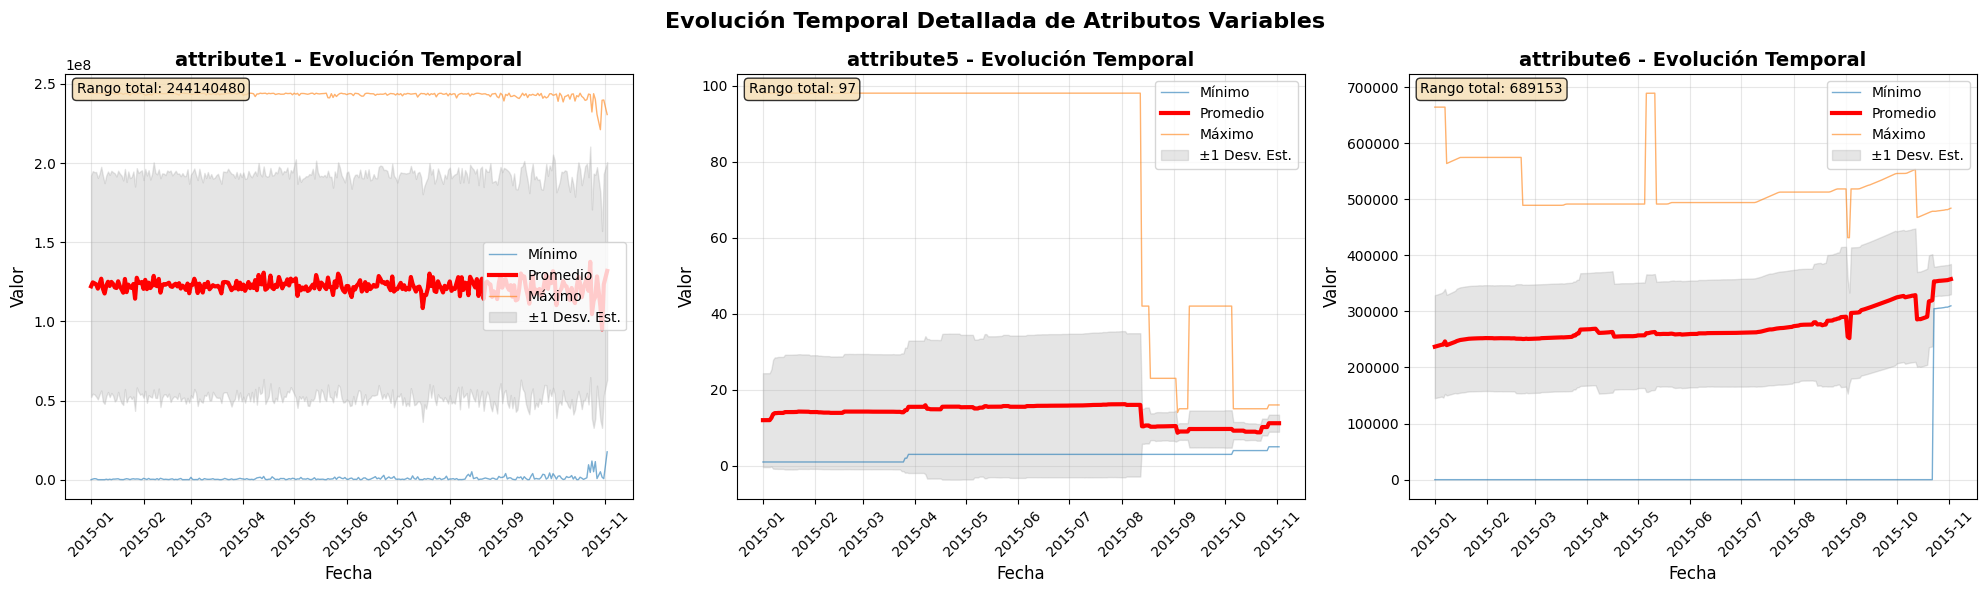

Gráficos detallados generados


In [9]:
# Gráficos separados para atributos más importantes
print("=== GRÁFICOS DETALLADOS DE ATRIBUTOS VARIABLES ===")

# Enfocarse en los atributos variables identificados anteriormente
variable_attrs = ['attribute1', 'attribute5', 'attribute6']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Evolución Temporal Detallada de Atributos Variables', fontsize=16, fontweight='bold')

for i, attr in enumerate(variable_attrs):
    # Calcular estadísticas por fecha
    daily_stats = df.groupby('date')[attr].agg(['min', 'mean', 'max', 'std']).reset_index()
    
    # Graficar con más detalle
    axes[i].plot(daily_stats['date'], daily_stats['min'], label='Mínimo', alpha=0.6, linewidth=1)
    axes[i].plot(daily_stats['date'], daily_stats['mean'], label='Promedio', linewidth=3, color='red')
    axes[i].plot(daily_stats['date'], daily_stats['max'], label='Máximo', alpha=0.6, linewidth=1)
    
    # Agregar banda de desviación estándar
    axes[i].fill_between(daily_stats['date'], 
                        daily_stats['mean'] - daily_stats['std'], 
                        daily_stats['mean'] + daily_stats['std'], 
                        alpha=0.2, label='±1 Desv. Est.', color='gray')
    
    # Configurar gráfico
    axes[i].set_title(f'{attr} - Evolución Temporal', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Fecha', fontsize=12)
    axes[i].set_ylabel('Valor', fontsize=12)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Rotar etiquetas de fecha
    axes[i].tick_params(axis='x', rotation=45)
    
    # Mostrar estadísticas en el título
    total_range = df[attr].max() - df[attr].min()
    axes[i].text(0.02, 0.98, f'Rango total: {total_range:.0f}', 
                transform=axes[i].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("Gráficos detallados generados")


In [10]:
# Resumen estadístico temporal por atributo
print("=== RESUMEN ESTADÍSTICO TEMPORAL ===")

for attr in attribute_cols:
    print(f"\n{attr.upper()}:")
    print("-" * 40)
    
    # Estadísticas por fecha
    daily_stats = df.groupby('date')[attr].agg(['min', 'mean', 'max', 'std']).reset_index()
    
    # Estadísticas generales
    print(f"Rango total: {df[attr].min():.4f} a {df[attr].max():.4f}")
    print(f"Promedio general: {df[attr].mean():.4f}")
    print(f"Desviación estándar general: {df[attr].std():.4f}")
    
    # Estadísticas temporales
    print(f"Promedio diario - Min: {daily_stats['mean'].min():.4f}, Max: {daily_stats['mean'].max():.4f}")
    print(f"Variabilidad diaria promedio: {daily_stats['std'].mean():.4f}")
    
    # Coeficiente de variación temporal
    cv_temporal = daily_stats['mean'].std() / daily_stats['mean'].mean()
    print(f"Coeficiente de variación temporal: {cv_temporal:.4f}")
    
    # Identificar días con valores extremos
    min_day = daily_stats.loc[daily_stats['min'].idxmin(), 'date']
    max_day = daily_stats.loc[daily_stats['max'].idxmax(), 'date']
    print(f"Día con valor mínimo: {min_day.strftime('%Y-%m-%d')}")
    print(f"Día con valor máximo: {max_day.strftime('%Y-%m-%d')}")

print("\n=== ANÁLISIS COMPLETADO ===")


=== RESUMEN ESTADÍSTICO TEMPORAL ===

ATTRIBUTE1:
----------------------------------------
Rango total: 0.0000 a 244140480.0000
Promedio general: 122388103.2421
Desviación estándar general: 70459334.2164
Promedio diario - Min: 94896394.5806, Max: 137593038.0000
Variabilidad diaria promedio: 70539596.7305
Coeficiente de variación temporal: 0.0360
Día con valor mínimo: 2015-01-01
Día con valor máximo: 2015-04-11

ATTRIBUTE2:
----------------------------------------
Rango total: 0.0000 a 64968.0000
Promedio general: 159.4848
Desviación estándar general: 2179.6577
Promedio diario - Min: 26.5306, Max: 2254.1935
Variabilidad diaria promedio: 1815.4528
Coeficiente de variación temporal: 1.8834
Día con valor mínimo: 2015-01-01
Día con valor máximo: 2015-07-16

ATTRIBUTE3:
----------------------------------------
Rango total: 0.0000 a 24929.0000
Promedio general: 9.9405
Desviación estándar general: 185.7473
Promedio diario - Min: 0.7867, Max: 71.7419
Variabilidad diaria promedio: 115.8830
Coefi

In [11]:
# Análisis de secuencias perfectas por dispositivo
print("=== ANÁLISIS DE SECUENCIAS PERFECTAS POR DISPOSITIVO ===")

# Crear columna de fecha truncada para análisis mensual
df['date_trunc'] = df['date'].astype(str).str[:7]

sequence_analysis = []

for device in df['device'].unique():
    device_data = df[df['device'] == device].sort_values('date')
    
    if len(device_data) < 2:
        continue
    
    # Análisis de gaps en fechas
    device_data['date_diff'] = device_data['date'].diff().dt.days
    gaps = device_data['date_diff'].dropna()
    
    # Identificar secuencias perfectas (gaps = 1 día)
    perfect_sequences = (gaps == 1).sum()
    total_gaps = len(gaps)
    imperfect_gaps = gaps[gaps != 1]
    
    # Análisis de rangos continuos
    consecutive_ranges = []
    current_start = device_data['date'].iloc[0]
    current_end = device_data['date'].iloc[0]
    
    for i in range(1, len(device_data)):
        gap = (device_data['date'].iloc[i] - device_data['date'].iloc[i-1]).days
        
        if gap == 1:  # Secuencia continua
            current_end = device_data['date'].iloc[i]
        else:  # Gap > 1
            # Guardar rango anterior
            consecutive_ranges.append({
                'start': current_start,
                'end': current_end,
                'duration_days': (current_end - current_start).days + 1
            })
            # Iniciar nuevo rango
            current_start = device_data['date'].iloc[i]
            current_end = device_data['date'].iloc[i]
    
    # Agregar último rango
    consecutive_ranges.append({
        'start': current_start,
        'end': current_end,
        'duration_days': (current_end - current_start).days + 1
    })
    
    # Estadísticas del dispositivo
    stats = {
        'device': device,
        'total_records': len(device_data),
        'date_span_days': (device_data['date'].max() - device_data['date'].min()).days + 1,
        'total_gaps': total_gaps,
        'perfect_gaps': perfect_sequences,
        'imperfect_gaps': len(imperfect_gaps),
        'perfect_gap_ratio': perfect_sequences / total_gaps if total_gaps > 0 else 1,
        'consecutive_ranges': len(consecutive_ranges),
        'max_consecutive_days': max([r['duration_days'] for r in consecutive_ranges]) if consecutive_ranges else 0,
        'is_perfect_sequence': perfect_sequences == total_gaps,
        'gap_details': imperfect_gaps.tolist() if len(imperfect_gaps) > 0 else []
    }
    
    sequence_analysis.append(stats)

sequence_df = pd.DataFrame(sequence_analysis)

print(f"Dispositivos analizados: {len(sequence_df)}")
print(f"Dispositivos con secuencia perfecta: {sequence_df['is_perfect_sequence'].sum()}")
print(f"Porcentaje con secuencia perfecta: {sequence_df['is_perfect_sequence'].mean() * 100:.2f}%")


=== ANÁLISIS DE SECUENCIAS PERFECTAS POR DISPOSITIVO ===
Dispositivos analizados: 1168
Dispositivos con secuencia perfecta: 995
Porcentaje con secuencia perfecta: 85.19%


In [12]:
# Ejemplos específicos de dispositivos con secuencias imperfectas
print("=== EJEMPLOS DE DISPOSITIVOS CON SECUENCIAS IMPERFECTAS ===")

# Obtener algunos ejemplos de dispositivos con secuencias imperfectas
imperfect_examples = sequence_df[~sequence_df['is_perfect_sequence']].head(5)

for idx, row in imperfect_examples.iterrows():
    device = row['device']
    device_data = df[df['device'] == device].sort_values('date')
    
    print(f"\nDispositivo: {device}")
    print(f"Total registros: {row['total_records']}")
    print(f"Ratio de secuencia perfecta: {row['perfect_gap_ratio']:.4f}")
    print(f"Rangos consecutivos: {row['consecutive_ranges']}")
    print(f"Máximo días consecutivos: {row['max_consecutive_days']}")
    
    # Mostrar gaps imperfectos
    device_data['date_diff'] = device_data['date'].diff().dt.days
    imperfect_gaps = device_data['date_diff'][device_data['date_diff'] != 1].dropna()
    
    print(f"Gaps imperfectos: {imperfect_gaps.tolist()}")
    
    # Mostrar fechas de inicio y fin de cada rango consecutivo
    consecutive_ranges = []
    current_start = device_data['date'].iloc[0]
    current_end = device_data['date'].iloc[0]
    
    for i in range(1, len(device_data)):
        gap = (device_data['date'].iloc[i] - device_data['date'].iloc[i-1]).days
        
        if gap == 1:  # Secuencia continua
            current_end = device_data['date'].iloc[i]
        else:  # Gap > 1
            consecutive_ranges.append({
                'start': current_start,
                'end': current_end,
                'duration': (current_end - current_start).days + 1
            })
            current_start = device_data['date'].iloc[i]
            current_end = device_data['date'].iloc[i]
    
    # Agregar último rango
    consecutive_ranges.append({
        'start': current_start,
        'end': current_end,
        'duration': (current_end - current_start).days + 1
    })
    
    print("Rangos consecutivos:")
    for i, rng in enumerate(consecutive_ranges[:3]):  # Mostrar solo los primeros 3
        print(f"  Rango {i+1}: {rng['start'].strftime('%Y-%m-%d')} a {rng['end'].strftime('%Y-%m-%d')} ({rng['duration']} días)")
    
    if len(consecutive_ranges) > 3:
        print(f"  ... y {len(consecutive_ranges) - 3} rangos más")


=== EJEMPLOS DE DISPOSITIVOS CON SECUENCIAS IMPERFECTAS ===

Dispositivo: S1F01R2B
Total registros: 223
Ratio de secuencia perfecta: 0.9955
Rangos consecutivos: 2
Máximo días consecutivos: 217
Gaps imperfectos: [14.0]
Rangos consecutivos:
  Rango 1: 2015-01-01 a 2015-01-06 (6 días)
  Rango 2: 2015-01-20 a 2015-08-24 (217 días)

Dispositivo: S1F02A0J
Total registros: 227
Ratio de secuencia perfecta: 0.9956
Rangos consecutivos: 2
Máximo días consecutivos: 221
Gaps imperfectos: [14.0]
Rangos consecutivos:
  Rango 1: 2015-01-01 a 2015-01-06 (6 días)
  Rango 2: 2015-01-20 a 2015-08-28 (221 días)

Dispositivo: S1F04DH8
Total registros: 25
Ratio de secuencia perfecta: 0.9583
Rangos consecutivos: 2
Máximo días consecutivos: 19
Gaps imperfectos: [58.0]
Rangos consecutivos:
  Rango 1: 2015-01-01 a 2015-01-06 (6 días)
  Rango 2: 2015-03-05 a 2015-03-23 (19 días)

Dispositivo: S1F06ZX2
Total registros: 112
Ratio de secuencia perfecta: 0.9910
Rangos consecutivos: 2
Máximo días consecutivos: 106
Gap

In [17]:
df[df['device']=='S1F01R2B']

,date,device,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9,date_trunc
115440,2015-08-24,S1F01R2B,0,45858720,0,0,0,19,344875,0,0,3,2015-08
115223,2015-08-23,S1F01R2B,0,21772720,0,0,0,19,343998,0,0,3,2015-08
115006,2015-08-22,S1F01R2B,0,242244968,0,0,0,19,343027,0,0,3,2015-08
114789,2015-08-21,S1F01R2B,0,125692296,0,0,0,19,342545,0,0,3,2015-08
114533,2015-08-20,S1F01R2B,0,100104264,0,0,0,19,341416,0,0,3,2015-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,2015-01-05,S1F01R2B,0,158255216,0,0,0,15,315360,0,0,3,2015-01
3493,2015-01-04,S1F01R2B,0,127529600,0,0,0,15,314088,0,0,3,2015-01
2330,2015-01-03,S1F01R2B,0,196415520,0,0,0,15,313173,0,0,3,2015-01
1167,2015-01-02,S1F01R2B,0,200864456,0,0,0,15,313173,0,0,3,2015-01


In [16]:
df = df.sort_values(['device', 'date'], ascending=[True, False])

#### FEATURE ENGINEERING

In [30]:


# Probar ingeniería de variables con un solo dispositivo
print("=== PRUEBA CON UN SOLO DISPOSITIVO ===")

# Filtrar solo un dispositivo para probar
test_device = 'S1F01R2B'
df_test = df[df['device'] == test_device].copy()
df_test = df_test.sort_values('date')

print(f"Dispositivo de prueba: {test_device}")
print(f"Registros del dispositivo: {len(df_test)}")
print(f"Rango de fechas: {df_test['date'].min()} a {df_test['date'].max()}")

# Mostrar datos originales
print(f"\nDatos originales del dispositivo:")
print(df_test[['device', 'date', 'attribute1', 'attribute5', 'attribute6']].head(10))

=== PRUEBA CON UN SOLO DISPOSITIVO ===
Dispositivo de prueba: S1F01R2B
Registros del dispositivo: 223
Rango de fechas: 2015-01-01 00:00:00 a 2015-08-24 00:00:00

Datos originales del dispositivo:
         device       date  attribute1  attribute5  attribute6
4      S1F01R2B 2015-01-01   135970480          15      313173
1167   S1F01R2B 2015-01-02   200864456          15      313173
2330   S1F01R2B 2015-01-03   196415520          15      313173
3493   S1F01R2B 2015-01-04   127529600          15      314088
4655   S1F01R2B 2015-01-05   158255216          15      315360
5816   S1F01R2B 2015-01-06   190692968          15      316629
16485  S1F01R2B 2015-01-20   127634552          17      328643
17198  S1F01R2B 2015-01-21   135284952          17      328989
17910  S1F01R2B 2015-01-22    10061096          17      329763
18622  S1F01R2B 2015-01-23    70633912          17      329763


In [31]:

# Función simple para calcular rezagos de un solo dispositivo
def calculate_lag_features_simple(df_single_device, value_col, windows=[7, 15, 30]):
    """
    Calcula rezagos para un solo dispositivo
    """
    result = df_single_device.copy()
    result = result.sort_values('date')
    
    for window in windows:
        print(f"Calculando ventana de {window} días para {value_col}...")
        
        # Inicializar columnas
        result[f'{value_col}_lag_{window}_min'] = np.nan
        result[f'{value_col}_lag_{window}_max'] = np.nan
        result[f'{value_col}_lag_{window}_mean'] = np.nan
        result[f'{value_col}_lag_{window}_std'] = np.nan
        
        values = result[value_col].values
        
        # Calcular ventana deslizante
        for i in range(len(values)):
            # Ventana hacia atrás
            start_idx = max(0, i - window + 1)
            end_idx = i + 1
            
            window_values = values[start_idx:end_idx]
            
            if len(window_values) > 0:
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_min')] = window_values.min()
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_max')] = window_values.max()
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_mean')] = window_values.mean()
                result.iloc[i, result.columns.get_loc(f'{value_col}_lag_{window}_std')] = window_values.std()
    
    return result

# Probar con attribute1
print("=== PROBANDO CON ATTRIBUTE1 ===")
df_test_with_lags = calculate_lag_features_simple(df_test, 'attribute1', windows=[7, 15, 30])

print(f"\nResultado con rezagos:")
cols_to_show = ['device', 'date', 'attribute1'] + [col for col in df_test_with_lags.columns if 'attribute1_lag' in col]
print(df_test_with_lags[cols_to_show].head(10))

=== PROBANDO CON ATTRIBUTE1 ===
Calculando ventana de 7 días para attribute1...
Calculando ventana de 15 días para attribute1...
Calculando ventana de 30 días para attribute1...

Resultado con rezagos:
         device       date  attribute1  attribute1_lag_7_min  \
4      S1F01R2B 2015-01-01   135970480           135970480.0   
1167   S1F01R2B 2015-01-02   200864456           135970480.0   
2330   S1F01R2B 2015-01-03   196415520           135970480.0   
3493   S1F01R2B 2015-01-04   127529600           127529600.0   
4655   S1F01R2B 2015-01-05   158255216           127529600.0   
5816   S1F01R2B 2015-01-06   190692968           127529600.0   
16485  S1F01R2B 2015-01-20   127634552           127529600.0   
17198  S1F01R2B 2015-01-21   135284952           127529600.0   
17910  S1F01R2B 2015-01-22    10061096            10061096.0   
18622  S1F01R2B 2015-01-23    70633912            10061096.0   

       attribute1_lag_7_max  attribute1_lag_7_mean  attribute1_lag_7_std  \
4               1

In [32]:

# Verificar manualmente algunos cálculos
print("=== VERIFICACIÓN MANUAL DE CÁLCULOS ===")

# Tomar las primeras 10 filas para verificar
sample = df_test_with_lags.head(10)

print("Verificación de attribute1_lag_7_mean:")
for i in range(min(7, len(sample))):
    row = sample.iloc[i]
    original_value = row['attribute1']
    lag_mean = row['attribute1_lag_7_mean']
    
    # Calcular manualmente el promedio de los últimos 7 días
    if i >= 6:  # Si tenemos al menos 7 registros
        manual_mean = sample['attribute1'].iloc[max(0, i-6):i+1].mean()
        print(f"Fila {i}: Original={original_value}, Lag_Mean={lag_mean:.2f}, Manual={manual_mean:.2f}")
    else:
        print(f"Fila {i}: Original={original_value}, Lag_Mean={lag_mean:.2f} (menos de 7 registros)")

print(f"\nVerificación de attribute1_lag_15_max:")
for i in range(min(15, len(sample))):
    row = sample.iloc[i]
    original_value = row['attribute1']
    lag_max = row['attribute1_lag_15_max']
    
    if i >= 14:  # Si tenemos al menos 15 registros
        manual_max = sample['attribute1'].iloc[max(0, i-14):i+1].max()
        print(f"Fila {i}: Original={original_value}, Lag_Max={lag_max:.2f}, Manual={manual_max:.2f}")
    else:
        print(f"Fila {i}: Original={original_value}, Lag_Max={lag_max:.2f} (menos de 15 registros)")
        break

=== VERIFICACIÓN MANUAL DE CÁLCULOS ===
Verificación de attribute1_lag_7_mean:
Fila 0: Original=135970480, Lag_Mean=135970480.00 (menos de 7 registros)
Fila 1: Original=200864456, Lag_Mean=168417468.00 (menos de 7 registros)
Fila 2: Original=196415520, Lag_Mean=177750152.00 (menos de 7 registros)
Fila 3: Original=127529600, Lag_Mean=165195014.00 (menos de 7 registros)
Fila 4: Original=158255216, Lag_Mean=163807054.40 (menos de 7 registros)
Fila 5: Original=190692968, Lag_Mean=168288040.00 (menos de 7 registros)
Fila 6: Original=127634552, Lag_Mean=162480398.86, Manual=162480398.86

Verificación de attribute1_lag_15_max:
Fila 0: Original=135970480, Lag_Max=135970480.00 (menos de 15 registros)


In [41]:
pd.set_option('display.max_columns', None)
df_test_with_lags.sort_values(by='date', ascending=False)

,date,device,failure,attribute1,attribute2,attribute3,attribute4,attribute5,attribute6,attribute7,attribute8,attribute9,date_trunc,attribute1_lag_7_min,attribute1_lag_7_max,attribute1_lag_7_mean,attribute1_lag_7_std,attribute1_lag_15_min,attribute1_lag_15_max,attribute1_lag_15_mean,attribute1_lag_15_std,attribute1_lag_30_min,attribute1_lag_30_max,attribute1_lag_30_mean,attribute1_lag_30_std
115440,2015-08-24,S1F01R2B,0,45858720,0,0,0,19,344875,0,0,3,2015-08,21772720.0,242244968.0,9.304346e+07,6.924195e+07,21772720.0,242244968.0,1.167952e+08,7.298988e+07,998096.0,242244968.0,1.143274e+08,7.268056e+07
115223,2015-08-23,S1F01R2B,0,21772720,0,0,0,19,343998,0,0,3,2015-08,21772720.0,242244968.0,1.046034e+08,6.712180e+07,21772720.0,242244968.0,1.276116e+08,7.369462e+07,998096.0,242244968.0,1.159721e+08,7.166373e+07
115006,2015-08-22,S1F01R2B,0,242244968,0,0,0,19,343027,0,0,3,2015-08,43738616.0,242244968.0,1.113043e+08,6.053654e+07,43738616.0,242244968.0,1.328808e+08,6.858738e+07,998096.0,242244968.0,1.202892e+08,6.973406e+07
114789,2015-08-21,S1F01R2B,0,125692296,0,0,0,19,342545,0,0,3,2015-08,43738616.0,240422864.0,1.110440e+08,5.997426e+07,998096.0,240422864.0,1.167977e+08,6.933780e+07,998096.0,240422864.0,1.142543e+08,6.668613e+07
114533,2015-08-20,S1F01R2B,0,100104264,0,0,0,19,341416,0,0,3,2015-08,43738616.0,240422864.0,1.102761e+08,5.981600e+07,998096.0,240422864.0,1.227285e+08,7.352328e+07,998096.0,240422864.0,1.111296e+08,6.825467e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,2015-01-05,S1F01R2B,0,158255216,0,0,0,15,315360,0,0,3,2015-01,127529600.0,200864456.0,1.638071e+08,3.019376e+07,127529600.0,200864456.0,1.638071e+08,3.019376e+07,127529600.0,200864456.0,1.638071e+08,3.019376e+07
3493,2015-01-04,S1F01R2B,0,127529600,0,0,0,15,314088,0,0,3,2015-01,127529600.0,200864456.0,1.651950e+08,3.361468e+07,127529600.0,200864456.0,1.651950e+08,3.361468e+07,127529600.0,200864456.0,1.651950e+08,3.361468e+07
2330,2015-01-03,S1F01R2B,0,196415520,0,0,0,15,313173,0,0,3,2015-01,135970480.0,200864456.0,1.777502e+08,2.959847e+07,135970480.0,200864456.0,1.777502e+08,2.959847e+07,135970480.0,200864456.0,1.777502e+08,2.959847e+07
1167,2015-01-02,S1F01R2B,0,200864456,0,0,0,15,313173,0,0,3,2015-01,135970480.0,200864456.0,1.684175e+08,3.244699e+07,135970480.0,200864456.0,1.684175e+08,3.244699e+07,135970480.0,200864456.0,1.684175e+08,3.244699e+07


In [42]:

# Aplicar ingeniería de variables a todo el dataset
print("=== APLICANDO INGENIERÍA A TODO EL DATASET ===")

# Crear copia del dataset ordenado
df_final = df.copy()
df_final = df_final.sort_values(['device', 'date'])

print(f"Dataset original: {df_final.shape}")
print(f"Dispositivos únicos: {df_final['device'].nunique()}")

# Definir atributos
high_variability_attrs = ['attribute1', 'attribute5', 'attribute6']  # Variables
low_variability_attrs = ['attribute2', 'attribute3', 'attribute4', 'attribute7', 'attribute8', 'attribute9']  # Invariables

print(f"Atributos de alta variabilidad: {high_variability_attrs}")
print(f"Atributos de baja variabilidad: {low_variability_attrs}")

=== APLICANDO INGENIERÍA A TODO EL DATASET ===
Dataset original: (124494, 13)
Dispositivos únicos: 1169
Atributos de alta variabilidad: ['attribute1', 'attribute5', 'attribute6']
Atributos de baja variabilidad: ['attribute2', 'attribute3', 'attribute4', 'attribute7', 'attribute8', 'attribute9']


In [ ]:

# Función escalable para calcular rezagos en todo el dataset
def calculate_lag_features_dataset(df, value_col, windows=[7, 15, 30, 60, 90, 120]):
    """
    Calcula rezagos para todo el dataset procesando por dispositivo
    """
    result = df.copy()
    
    # Inicializar columnas
    for window in windows:
        result[f'{value_col}_lag_{window}_min'] = np.nan
        result[f'{value_col}_lag_{window}_max'] = np.nan
        result[f'{value_col}_lag_{window}_mean'] = np.nan
        result[f'{value_col}_lag_{window}_std'] = np.nan
    
    # Procesar cada dispositivo
    devices = df['device'].unique()
    total_devices = len(devices)
    
    for idx, device in enumerate(devices):
        if idx % 100 == 0:
            print(f"  Procesando dispositivo {idx+1}/{total_devices}: {device}")
        
        device_mask = df['device'] == device
        device_data = df[device_mask].sort_values('date')
        
        if len(device_data) == 0:
            continue
        
        values = device_data[value_col].values
        
        # Calcular para cada ventana
        for window in windows:
            for i in range(len(values)):
                # Ventana hacia atrás
                start_idx = max(0, i - window + 1)
                end_idx = i + 1
                
                window_values = values[start_idx:end_idx]
                
                if len(window_values) > 0:
                    # Obtener índices en el dataframe original
                    device_indices = device_data.index[start_idx:end_idx]
                    
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_min'] = window_values.min()
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_max'] = window_values.max()
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_mean'] = window_values.mean()
                    result.loc[device_data.index[i], f'{value_col}_lag_{window}_std'] = window_values.std()
    
    return result

# Aplicar rezagos para atributos de alta variabilidad
print("=== PROCESANDO ATRIBUTOS DE ALTA VARIABILIDAD ===")

for attr in high_variability_attrs:
    print(f"\nProcesando {attr}...")
    df_final = calculate_lag_features_dataset(
        df_final, 
        attr, 
        windows=[7, 15, 30, 60, 90, 120]
    )
    print(f"  ✅ Completado {attr}")

print(f"\nDataset después de alta variabilidad: {df_final.shape}")

In [29]:
df_with_features[df_with_features['device']=='S1F01R2B'].to_excel('C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_ejemplo_processed.xlsx', index=False)

In [ ]:
df_with_features.head(2)

In [ ]:
df_with_features.to_parquet('C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_exer3_processed.parquet')